# ResNet293 Embedding Space Analysis

Understanding **how** the model separates speakers and detects spoof, by analyzing the 256-dim embedding space directly.

Pipeline: `Audio -> fbank -> ResNet293 -> 256-dim embedding -> StandardScaler -> LogisticRegression -> spoof score`

The ResNet293 was trained for **speaker verification** (separating speakers). The logistic regression then found a **linear direction** in embedding space that separates spoof from bonafide.

## Sections
1. Load data (cached embeddings + manifest + logistic model)
2. Logistic coefficient analysis (which embedding dimensions detect spoof)
3. Per-dimension distributions (spoof vs bonafide)
4. Same-speaker paired delta (the empirical "spoof direction")
5. Cosine similarity analysis (speaker identity vs spoof effects)
6. t-SNE embedding visualization


In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity


## 1. Load Data


In [2]:
# ===== Config =====
MODEL_DIR = Path('/home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems_global_excluding_a12_resnet293')

# Load manifest
meta_df = pd.read_csv(MODEL_DIR / 'training_manifest_used.csv')

# Load embeddings (train partition + dev partition)
emb_train = np.load(MODEL_DIR / 'embeddings_train_global_excluding_a12.npz', allow_pickle=True)
emb_dev = np.load(MODEL_DIR / 'embeddings_dev_global_excluding_a12.npz', allow_pickle=True)
X_all = np.concatenate([emb_train['X'], emb_dev['X']], axis=0)
utt_ids_all = np.concatenate([emb_train['utt_ids'], emb_dev['utt_ids']], axis=0)

# Align embeddings with manifest
utt_to_idx = {uid: i for i, uid in enumerate(utt_ids_all)}
aligned_idx = meta_df['utt_id'].map(utt_to_idx).to_numpy()
assert not np.any(np.isnan(aligned_idx.astype(float))), 'Some utt_ids not found in embeddings'
X = X_all[aligned_idx.astype(int)]
y = meta_df['binary_label'].to_numpy()

# Load logistic regression + scaler
with open(MODEL_DIR / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(MODEL_DIR / 'logistic_regression.pkl', 'rb') as f:
    clf = pickle.load(f)

print(f'Embeddings: {X.shape}')
print(f'Manifest: {len(meta_df)} rows')
print(f'Speakers: {meta_df["speaker_id"].nunique()}')
print(f'Bonafide: {(y == 0).sum()}, Spoof: {(y == 1).sum()}')
print(f'Systems: {sorted(meta_df["system_id"].unique().tolist())}')
print(f'Logistic coef shape: {clf.coef_.shape}, intercept: {clf.intercept_[0]:.4f}')


Embeddings: (246628, 256)
Manifest: 246628 rows
Speakers: 792
Bonafide: 27404, Spoof: 219224
Systems: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'bonafide']
Logistic coef shape: (1, 256), intercept: 5.1087


/home/SpeakerRec/BioVoice/.venv/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/SpeakerRec/BioVoice/.venv/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Logistic Regression Coefficient Analysis

The logistic regression has 256 coefficients (one per embedding dimension) + intercept.
Each coefficient tells us how much that dimension contributes to the spoof score.
**Positive coef** = higher value in that dimension pushes toward spoof.
**Negative coef** = higher value pushes toward bonafide.


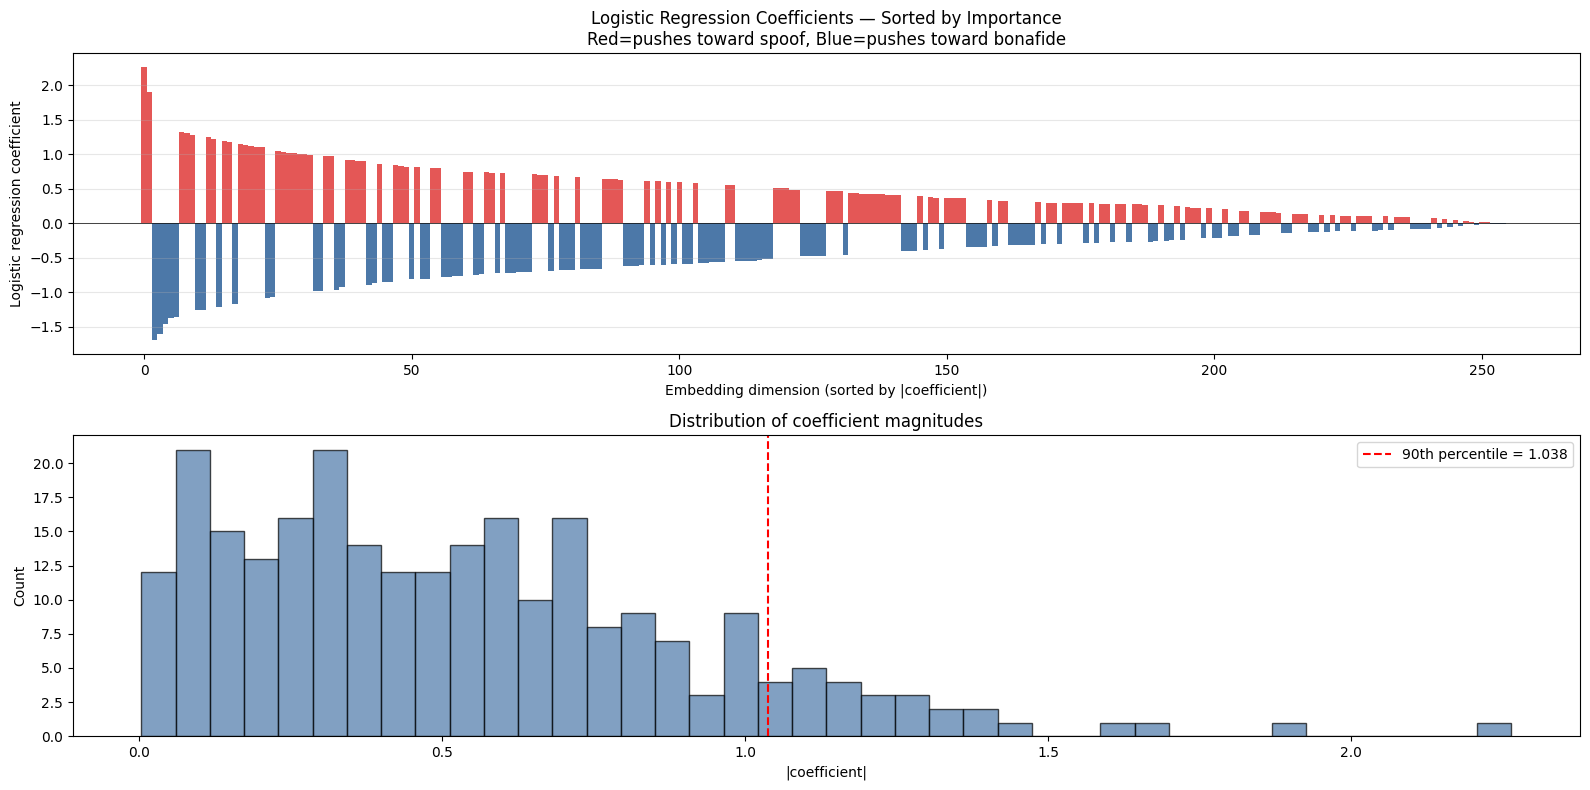

Top 20 most important embedding dimensions:


,dim,coefficient,abs_coefficient,direction
0,201,2.264706,2.264706,-> spoof
1,151,1.899727,1.899727,-> spoof
2,1,-1.697565,1.697565,-> bonafide
3,249,-1.603322,1.603322,-> bonafide
4,124,-1.456728,1.456728,-> bonafide
5,76,-1.374977,1.374977,-> bonafide
6,47,-1.360864,1.360864,-> bonafide
7,218,1.326142,1.326142,-> spoof
8,232,1.309058,1.309058,-> spoof
9,46,1.280933,1.280933,-> spoof



These 20 dims account for 20.3% of total coefficient mass.


In [3]:
coefs = clf.coef_[0]  # (256,)
abs_coefs = np.abs(coefs)
dim_order = np.argsort(-abs_coefs)  # sorted by importance

# Plot all coefficients
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Bar plot sorted by magnitude
ax = axes[0]
colors = ['#E45756' if c > 0 else '#4C78A8' for c in coefs[dim_order]]
ax.bar(range(256), coefs[dim_order], color=colors, width=1.0)
ax.set_xlabel('Embedding dimension (sorted by |coefficient|)')
ax.set_ylabel('Logistic regression coefficient')
ax.set_title('Logistic Regression Coefficients — Sorted by Importance\n'
             'Red=pushes toward spoof, Blue=pushes toward bonafide')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Coefficient magnitude histogram
ax = axes[1]
ax.hist(abs_coefs, bins=40, color='#4C78A8', edgecolor='black', alpha=0.7)
ax.set_xlabel('|coefficient|')
ax.set_ylabel('Count')
ax.set_title('Distribution of coefficient magnitudes')
ax.axvline(x=np.percentile(abs_coefs, 90), color='red', linestyle='--',
           label=f'90th percentile = {np.percentile(abs_coefs, 90):.3f}')
ax.legend()

plt.tight_layout()
plt.show()

# Top-20 most important dimensions
top_k = 20
top_dims = dim_order[:top_k]
top_df = pd.DataFrame({
    'dim': top_dims,
    'coefficient': coefs[top_dims],
    'abs_coefficient': abs_coefs[top_dims],
    'direction': ['-> spoof' if c > 0 else '-> bonafide' for c in coefs[top_dims]],
})
print(f'Top {top_k} most important embedding dimensions:')
display(top_df)
print(f'\nThese {top_k} dims account for '
      f'{abs_coefs[top_dims].sum() / abs_coefs.sum() * 100:.1f}% '
      f'of total coefficient mass.')


## 3. Per-Dimension Distributions (Spoof vs Bonafide)

For the most important dimensions, compare the raw embedding value distributions
between bonafide and spoof. If the distributions are well-separated, that dimension
is genuinely useful for spoof detection.


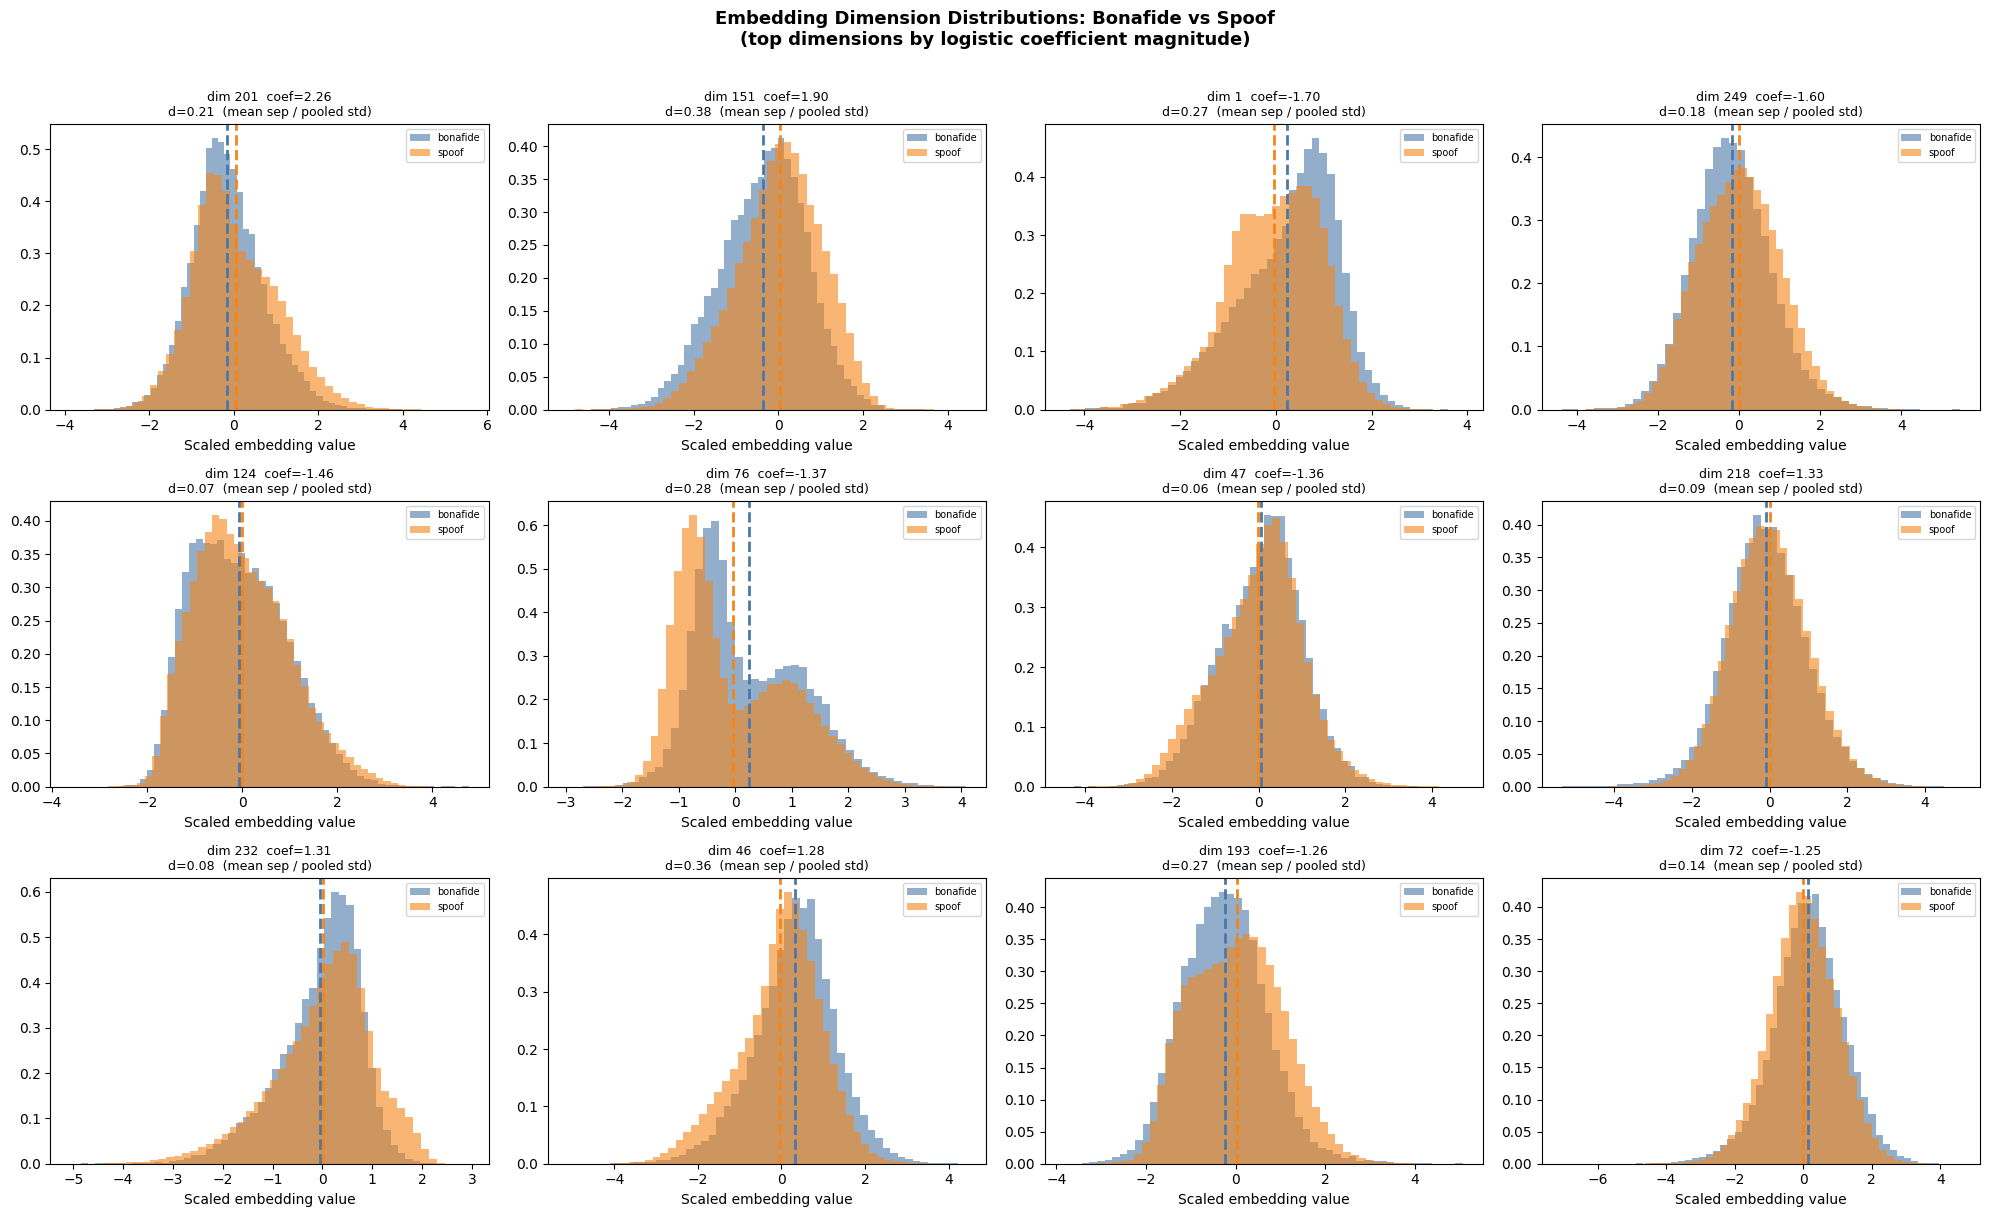

In [4]:
# Scale embeddings the same way the logistic regression sees them
X_scaled = scaler.transform(X)

top_k_plot = 12
dims_to_plot = dim_order[:top_k_plot]

ncols = 4
nrows = (top_k_plot + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

bonafide_mask = y == 0
spoof_mask = y == 1

for i, dim in enumerate(dims_to_plot):
    ax = axes[i]
    vals_b = X_scaled[bonafide_mask, dim]
    vals_s = X_scaled[spoof_mask, dim]

    ax.hist(vals_b, bins=50, alpha=0.6, color='#4C78A8', label='bonafide', density=True)
    ax.hist(vals_s, bins=50, alpha=0.6, color='#F58518', label='spoof', density=True)
    ax.axvline(x=vals_b.mean(), color='#4C78A8', linestyle='--', linewidth=2)
    ax.axvline(x=vals_s.mean(), color='#F58518', linestyle='--', linewidth=2)

    coef_val = coefs[dim]
    sep = abs(vals_s.mean() - vals_b.mean()) / np.sqrt((vals_s.std()**2 + vals_b.std()**2) / 2)
    ax.set_title(f'dim {dim}  coef={coef_val:.2f}\n'
                 f'd={sep:.2f}  (mean sep / pooled std)', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel('Scaled embedding value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Embedding Dimension Distributions: Bonafide vs Spoof\n'
             '(top dimensions by logistic coefficient magnitude)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Same-Speaker Paired Delta: The Empirical "Spoof Direction"

For each speaker who has **both** bonafide and spoof utterances, compute:

`delta = mean(spoof_embeddings) - mean(bonafide_embeddings)`

This removes speaker identity and isolates the **spoof effect** — what changes in
embedding space when the same person's voice is spoofed.

Then compare this empirical spoof direction with the logistic regression coefficients.


Speakers with both bonafide and spoof: 769
Average delta shape: (256,)

Correlation between logistic coefs and empirical spoof direction: 0.2096
(High positive correlation = the logistic regression learned the same direction
 that empirically separates spoof from bonafide for the same speakers)


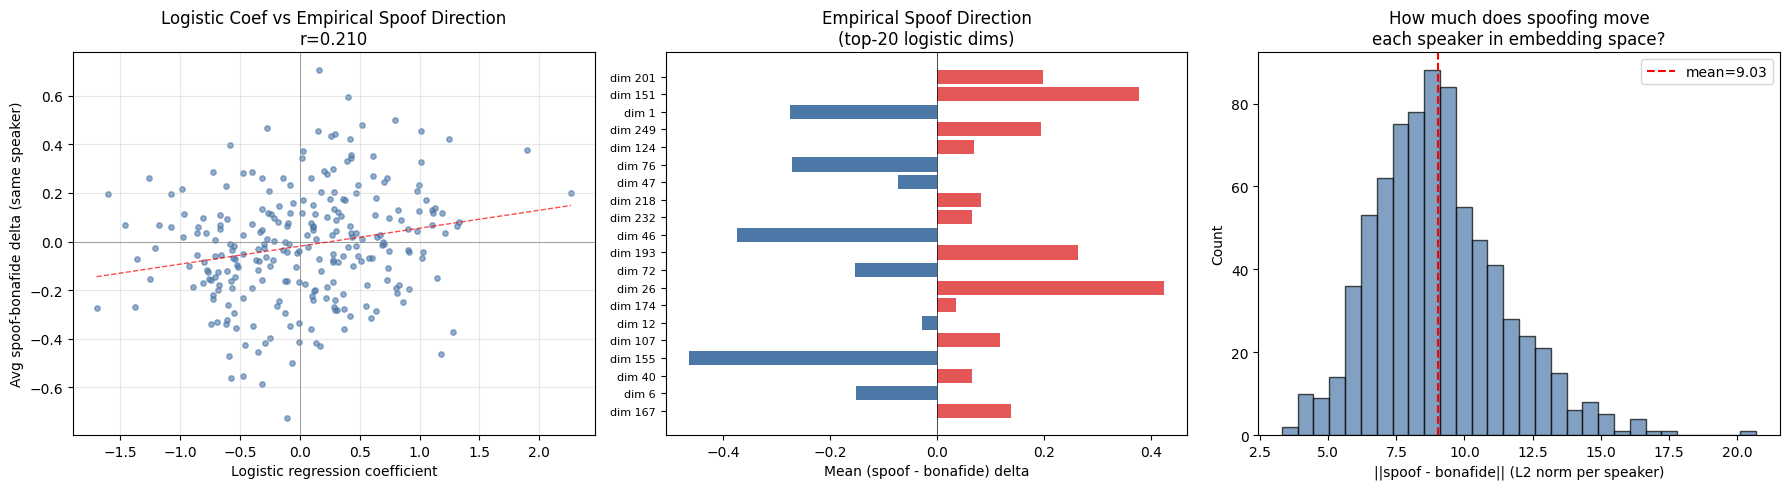

In [5]:
# Compute per-speaker mean embeddings for bonafide and spoof
speaker_deltas = []
speaker_ids_with_both = []

for speaker_id in meta_df['speaker_id'].unique():
    sp_mask = meta_df['speaker_id'] == speaker_id
    sp_bonafide = sp_mask & (y == 0)
    sp_spoof = sp_mask & (y == 1)

    if sp_bonafide.sum() < 5 or sp_spoof.sum() < 5:
        continue

    mean_bonafide = X_scaled[sp_bonafide.to_numpy()].mean(axis=0)
    mean_spoof = X_scaled[sp_spoof.to_numpy()].mean(axis=0)
    delta = mean_spoof - mean_bonafide
    speaker_deltas.append(delta)
    speaker_ids_with_both.append(speaker_id)

speaker_deltas = np.stack(speaker_deltas)  # (n_speakers, 256)
avg_delta = speaker_deltas.mean(axis=0)     # (256,) — the average spoof direction

print(f'Speakers with both bonafide and spoof: {len(speaker_ids_with_both)}')
print(f'Average delta shape: {avg_delta.shape}')

# Correlation between logistic coefficients and empirical spoof direction
correlation = np.corrcoef(coefs, avg_delta)[0, 1]
print(f'\nCorrelation between logistic coefs and empirical spoof direction: {correlation:.4f}')
print('(High positive correlation = the logistic regression learned the same direction')
print(' that empirically separates spoof from bonafide for the same speakers)')

# Plot: logistic coefs vs empirical delta
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: coef vs delta
ax = axes[0]
ax.scatter(coefs, avg_delta, s=15, alpha=0.6, c='#4C78A8')
ax.set_xlabel('Logistic regression coefficient')
ax.set_ylabel('Avg spoof-bonafide delta (same speaker)')
ax.set_title(f'Logistic Coef vs Empirical Spoof Direction\nr={correlation:.3f}')
ax.axhline(y=0, color='grey', linewidth=0.5)
ax.axvline(x=0, color='grey', linewidth=0.5)
# Add regression line
z = np.polyfit(coefs, avg_delta, 1)
p = np.poly1d(z)
x_line = np.linspace(coefs.min(), coefs.max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=1, alpha=0.7)
ax.grid(alpha=0.3)

# Average delta bar plot (top dims)
ax = axes[1]
top_20 = dim_order[:20]
colors = ['#E45756' if d > 0 else '#4C78A8' for d in avg_delta[top_20]]
ax.barh(range(20), avg_delta[top_20], color=colors)
ax.set_yticks(range(20))
ax.set_yticklabels([f'dim {d}' for d in top_20], fontsize=8)
ax.set_xlabel('Mean (spoof - bonafide) delta')
ax.set_title('Empirical Spoof Direction\n(top-20 logistic dims)')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.invert_yaxis()

# Per-speaker delta variance
ax = axes[2]
delta_norms = np.linalg.norm(speaker_deltas, axis=1)
ax.hist(delta_norms, bins=30, color='#4C78A8', edgecolor='black', alpha=0.7)
ax.axvline(x=delta_norms.mean(), color='red', linestyle='--',
           label=f'mean={delta_norms.mean():.2f}')
ax.set_xlabel('||spoof - bonafide|| (L2 norm per speaker)')
ax.set_ylabel('Count')
ax.set_title('How much does spoofing move\neach speaker in embedding space?')
ax.legend()

plt.tight_layout()
plt.show()


## 5. Cosine Similarity Analysis

How does the model see relationships between utterances?
- **Same speaker, same class**: should be very similar (model trained for speaker verification)
- **Same speaker, cross class** (bonafide vs spoof): how much does spoofing hurt speaker identity?
- **Different speaker**: should be dissimilar


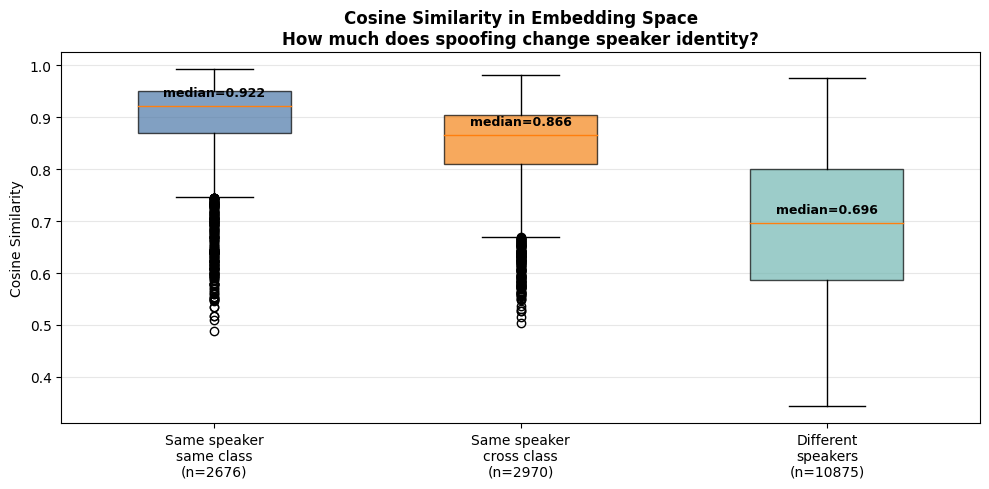

Key finding:
  Same speaker, same class:  median cosine sim = 0.9215
  Same speaker, cross class: median cosine sim = 0.8657
  Different speakers:        median cosine sim = 0.6956

  Spoofing drops cosine sim by 0.0559 for the same speaker.
  If this drop is small, the spoof preserves speaker identity well
  and the model must use subtle cues to detect it.


In [6]:
# Subsample for speed (cosine similarity on 246K x 246K is too big)
rng = np.random.default_rng(42)
n_speakers_sample = 30
n_utts_per_group = 10  # per speaker per class

# Pick speakers that have both bonafide and spoof
sampled_speakers = rng.choice(speaker_ids_with_both, size=min(n_speakers_sample, len(speaker_ids_with_both)), replace=False)

sim_same_spk_same_cls = []   # same speaker, same class
sim_same_spk_cross_cls = []  # same speaker, bonafide vs spoof
sim_diff_spk = []            # different speakers

for speaker_id in sampled_speakers:
    sp_mask = meta_df['speaker_id'] == speaker_id
    idx_b = np.where((sp_mask & (y == 0)).to_numpy())[0]
    idx_s = np.where((sp_mask & (y == 1)).to_numpy())[0]

    if len(idx_b) < 2 or len(idx_s) < 2:
        continue

    idx_b = rng.choice(idx_b, size=min(n_utts_per_group, len(idx_b)), replace=False)
    idx_s = rng.choice(idx_s, size=min(n_utts_per_group, len(idx_s)), replace=False)

    emb_b = X[idx_b]
    emb_s = X[idx_s]

    # Same speaker, same class (bonafide-bonafide)
    cs_bb = cosine_similarity(emb_b)
    triu = np.triu_indices_from(cs_bb, k=1)
    sim_same_spk_same_cls.extend(cs_bb[triu].tolist())

    # Same speaker, same class (spoof-spoof)
    cs_ss = cosine_similarity(emb_s)
    triu = np.triu_indices_from(cs_ss, k=1)
    sim_same_spk_same_cls.extend(cs_ss[triu].tolist())

    # Same speaker, cross class
    cs_bs = cosine_similarity(emb_b, emb_s)
    sim_same_spk_cross_cls.extend(cs_bs.flatten().tolist())

# Different speakers
for i in range(min(50, len(sampled_speakers))):
    for j in range(i + 1, min(50, len(sampled_speakers))):
        sp1 = sampled_speakers[i]
        sp2 = sampled_speakers[j]
        idx1 = np.where((meta_df['speaker_id'] == sp1).to_numpy())[0][:5]
        idx2 = np.where((meta_df['speaker_id'] == sp2).to_numpy())[0][:5]
        cs = cosine_similarity(X[idx1], X[idx2])
        sim_diff_spk.extend(cs.flatten().tolist())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
data = [sim_same_spk_same_cls, sim_same_spk_cross_cls, sim_diff_spk]
labels = [
    f'Same speaker\nsame class\n(n={len(sim_same_spk_same_cls)})',
    f'Same speaker\ncross class\n(n={len(sim_same_spk_cross_cls)})',
    f'Different\nspeakers\n(n={len(sim_diff_spk)})',
]
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
colors_box = ['#4C78A8', '#F58518', '#72B7B2']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Cosine Similarity')
ax.set_title('Cosine Similarity in Embedding Space\n'
             'How much does spoofing change speaker identity?',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, d in enumerate(data):
    ax.text(i + 1, np.median(d) + 0.02, f'median={np.median(d):.3f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('Key finding:')
print(f'  Same speaker, same class:  median cosine sim = {np.median(sim_same_spk_same_cls):.4f}')
print(f'  Same speaker, cross class: median cosine sim = {np.median(sim_same_spk_cross_cls):.4f}')
print(f'  Different speakers:        median cosine sim = {np.median(sim_diff_spk):.4f}')
drop = np.median(sim_same_spk_same_cls) - np.median(sim_same_spk_cross_cls)
print(f'\n  Spoofing drops cosine sim by {drop:.4f} for the same speaker.')
print('  If this drop is small, the spoof preserves speaker identity well')
print('  and the model must use subtle cues to detect it.')


## 6. t-SNE Embedding Visualization

Visualize the 256-dim embedding space projected to 2D.
We subsample for speed and color by different attributes.


In [7]:
# Subsample for t-SNE (too slow on 246K)
n_sample = 5000
rng_tsne = np.random.default_rng(42)

# Stratified sample: equal bonafide and spoof
idx_b = np.where(y == 0)[0]
idx_s = np.where(y == 1)[0]
n_per_class = n_sample // 2
sample_b = rng_tsne.choice(idx_b, size=min(n_per_class, len(idx_b)), replace=False)
sample_s = rng_tsne.choice(idx_s, size=min(n_per_class, len(idx_s)), replace=False)
sample_idx = np.concatenate([sample_b, sample_s])
rng_tsne.shuffle(sample_idx)

X_sample = X_scaled[sample_idx]
meta_sample = meta_df.iloc[sample_idx].copy().reset_index(drop=True)
y_sample = y[sample_idx]

print(f'Running t-SNE on {len(sample_idx)} samples...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_sample)
print('t-SNE done.')


Running t-SNE on 5000 samples...
t-SNE done.


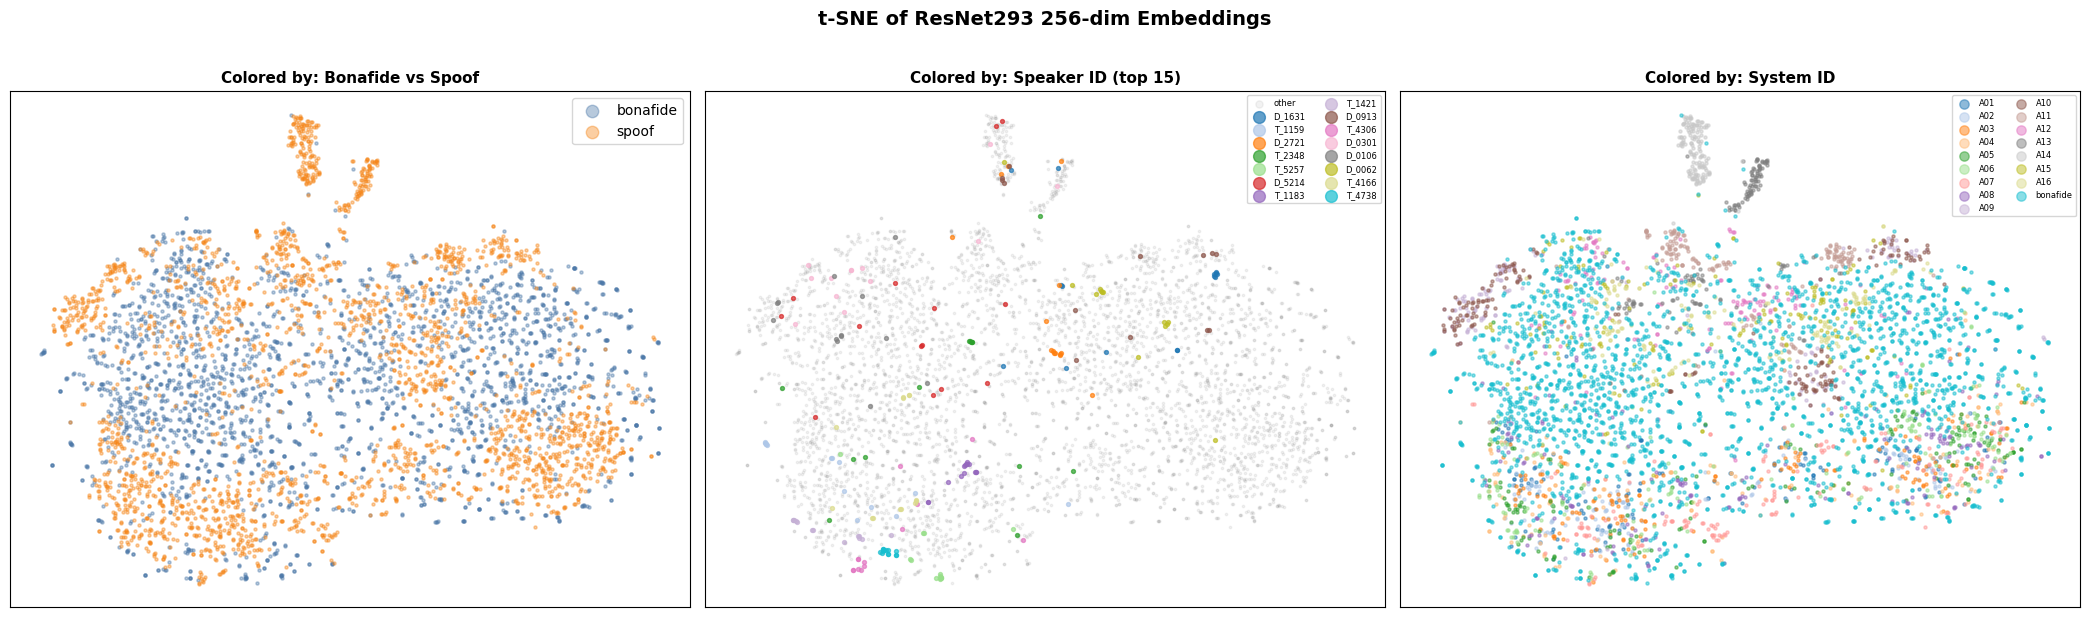

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1. Color by bonafide / spoof
ax = axes[0]
colors_class = np.where(y_sample == 0, '#4C78A8', '#F58518')
ax.scatter(X_2d[y_sample == 0, 0], X_2d[y_sample == 0, 1],
           s=5, alpha=0.4, c='#4C78A8', label='bonafide')
ax.scatter(X_2d[y_sample == 1, 0], X_2d[y_sample == 1, 1],
           s=5, alpha=0.4, c='#F58518', label='spoof')
ax.set_title('Colored by: Bonafide vs Spoof', fontsize=11, fontweight='bold')
ax.legend(markerscale=4)
ax.set_xticks([])
ax.set_yticks([])

# 2. Color by speaker (top 15 speakers with most samples)
ax = axes[1]
top_speakers = meta_sample['speaker_id'].value_counts().head(15).index.tolist()
cmap = plt.cm.tab20
# Plot "other" speakers as grey background first
other_mask = ~meta_sample['speaker_id'].isin(top_speakers)
ax.scatter(X_2d[other_mask, 0], X_2d[other_mask, 1],
           s=3, alpha=0.1, c='grey', label='other')
for idx_sp, sp in enumerate(top_speakers):
    sp_mask = (meta_sample['speaker_id'] == sp).to_numpy()
    ax.scatter(X_2d[sp_mask, 0], X_2d[sp_mask, 1],
               s=8, alpha=0.7, c=[cmap(idx_sp / 15)], label=sp)
ax.set_title('Colored by: Speaker ID (top 15)', fontsize=11, fontweight='bold')
ax.legend(fontsize=6, ncol=2, markerscale=3, loc='upper right')
ax.set_xticks([])
ax.set_yticks([])

# 3. Color by spoof system
ax = axes[2]
systems = sorted(meta_sample['system_id'].unique().tolist())
cmap_sys = plt.cm.tab20
for idx_sys, sys_id in enumerate(systems):
    sys_mask = (meta_sample['system_id'] == sys_id).to_numpy()
    ax.scatter(X_2d[sys_mask, 0], X_2d[sys_mask, 1],
               s=5, alpha=0.5, c=[cmap_sys(idx_sys / len(systems))], label=sys_id)
ax.set_title('Colored by: System ID', fontsize=11, fontweight='bold')
ax.legend(fontsize=6, ncol=2, markerscale=3, loc='upper right')
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle('t-SNE of ResNet293 256-dim Embeddings',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Per-System Spoof Direction

Does each spoof system shift embeddings in the **same** direction, or do different
systems have different signatures?


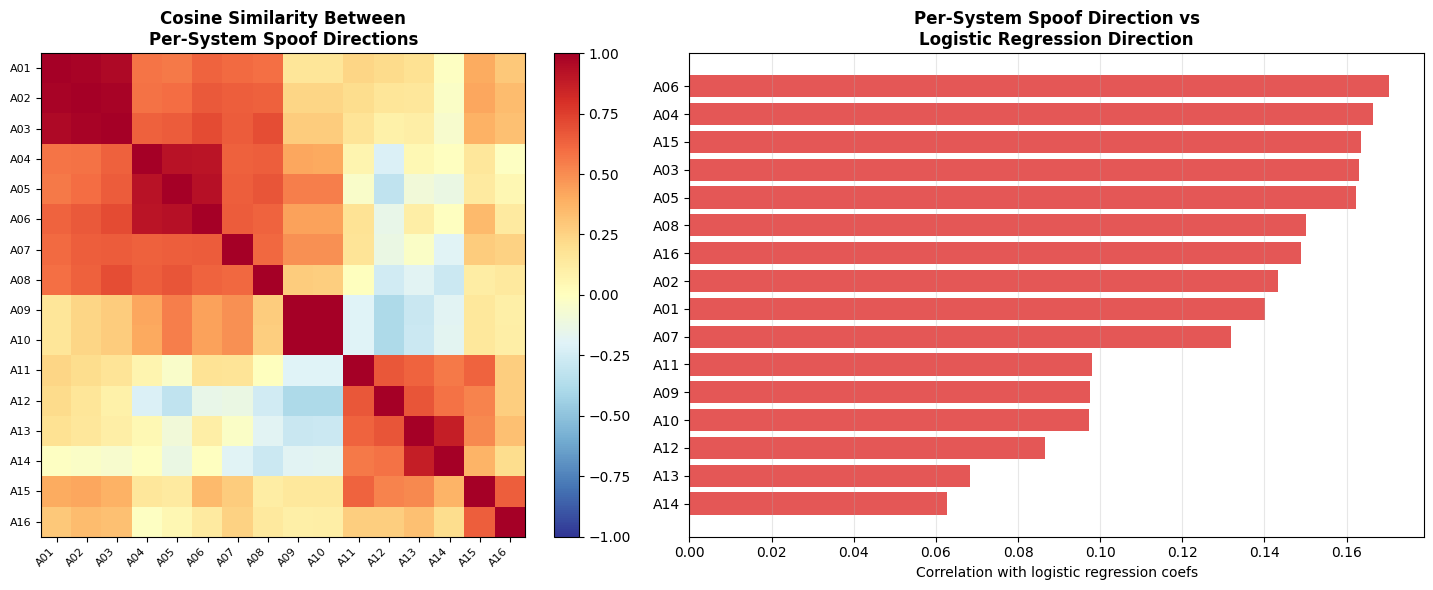

,system,corr_with_logreg
5,A06,0.1703
3,A04,0.1665
14,A15,0.1636
2,A03,0.1631
4,A05,0.1622
7,A08,0.1501
15,A16,0.1488
1,A02,0.1434
0,A01,0.1401
6,A07,0.1318



Interpretation:
  High positive correlation = this system shifts embeddings in the direction
  the logistic regression learned to detect.
  Near-zero correlation = the model detects this system via a different mechanism.


In [9]:
# Compute per-system average delta
spoof_systems = sorted([s for s in meta_df['system_id'].unique() if s != 'bonafide'])
system_deltas = {}

for sys_id in spoof_systems:
    deltas = []
    for speaker_id in speaker_ids_with_both:
        sp_mask = meta_df['speaker_id'] == speaker_id
        # Bonafide for this speaker
        idx_b = np.where((sp_mask & (y == 0)).to_numpy())[0]
        # Spoof for this speaker from this specific system
        idx_s = np.where((sp_mask & (meta_df['system_id'] == sys_id)).to_numpy())[0]
        if len(idx_b) < 3 or len(idx_s) < 3:
            continue
        delta = X_scaled[idx_s].mean(axis=0) - X_scaled[idx_b].mean(axis=0)
        deltas.append(delta)
    if deltas:
        system_deltas[sys_id] = np.mean(np.stack(deltas), axis=0)

# Compute pairwise cosine similarity between system deltas
sys_names = list(system_deltas.keys())
delta_matrix = np.stack([system_deltas[s] for s in sys_names])
sys_cos_sim = cosine_similarity(delta_matrix)

# Also compare each system delta with the logistic coefficients
sys_vs_logreg = []
for sys_id in sys_names:
    corr = np.corrcoef(coefs, system_deltas[sys_id])[0, 1]
    sys_vs_logreg.append({'system': sys_id, 'corr_with_logreg': round(corr, 4)})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: system delta similarities
ax = axes[0]
im = ax.imshow(sys_cos_sim, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(sys_names)))
ax.set_xticklabels(sys_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(sys_names)))
ax.set_yticklabels(sys_names, fontsize=8)
ax.set_title('Cosine Similarity Between\nPer-System Spoof Directions', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Bar: correlation of each system delta with logistic coefs
ax = axes[1]
corr_df = pd.DataFrame(sys_vs_logreg).sort_values('corr_with_logreg', ascending=True)
colors_bar = ['#E45756' if c > 0 else '#4C78A8' for c in corr_df['corr_with_logreg']]
ax.barh(corr_df['system'], corr_df['corr_with_logreg'], color=colors_bar)
ax.set_xlabel('Correlation with logistic regression coefs')
ax.set_title('Per-System Spoof Direction vs\nLogistic Regression Direction', fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

display(pd.DataFrame(sys_vs_logreg).sort_values('corr_with_logreg', ascending=False))

print('\nInterpretation:')
print('  High positive correlation = this system shifts embeddings in the direction')
print('  the logistic regression learned to detect.')
print('  Near-zero correlation = the model detects this system via a different mechanism.')
